# Goal
Analyze the export performance of semiconductor products (specifically integrated circuits) by destination country to identify high-value markets and trends using trade data.

# Data Loading

| Column                                                 | Description                                                                                         |
| ------------------------------------------------------ | --------------------------------------------------------------------------------------------------- |
| **typeCode**                                           | Type of dataset (e.g., trade data category, usually 'C' for commodity)                              |
| **freqCode**                                           | Frequency of the data (usually annual or monthly)                                                   |
| **refPeriodId**, **refYear**, **refMonth**, **period** | Time indicators — useful for time-series analysis                                                   |
| **reporterCode**, **reporterISO**, **reporterDesc**    | Country that is reporting the trade (e.g., Taiwan)                                                  |
| **flowCode**, **flowDesc**                             | Type of trade: Import or Export                                                                     |
| **partnerCode**, **partnerISO**, **partnerDesc**       | Trade partner (who you're buying from or selling to)                                                |
| **cmdCode**                                            | HS (Harmonized System) commodity code — identifies the product (e.g., 8542 for ICs)                 |
| **cmdDesc**                                            | Product description (e.g., “Electronic integrated circuits”)                                        |
| **qty**, **netWgt**, **grossWgt**                      | Quantity and weight of traded goods (may be True/False if not filled correctly)                     |
| **fobvalue**                                           | **Free On Board** value — cost of goods at point of export (good for export-focused value)          |
| **cifvalue**                                           | **Cost, Insurance, and Freight** — includes shipping/import costs (useful for import-side analysis) |
| **motCode**, **motDesc**                               | Mode of transport (e.g., sea, air)                                                                  |
| **customsCode**, **customsDesc**                       | Customs declaration info                                                                            |
| **qtyUnitCode**, **qtyUnitAbbr**                       | Units of measurement (e.g., kg, pieces)                                                             |
| **isReported**                                         | Whether the data is officially reported (vs. estimated)                                             |

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import platform
from pathlib import Path
from math import sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error
pd.reset_option('display.max_rows')

In [ ]:
base_path = Path("D:/Git_folder/Dibimbing---DSDA/Final Project Data Science/data_monthly")


if platform.system() == "Windows":
    base_path = Path("D:/Git_folder/Dibimbing---DSDA/Final Project Data Science/data_monthly")
else:
    base_path = Path("/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly")

file_names = [
    "TradeDataJan25.csv", "TradeDataFeb25.csv", "TradeDataMar25.csv", "TradeDataApr25.csv",
    "TradeDataMay25.csv", "TradeDataJan24.csv", "TradeDataFeb24.csv",
    "TradeDataMar24.csv", "TradeDataApr24.csv", "TradeDataMay24.csv", "TradeDataJune24.csv",
    "TradeDataJuly24.csv", "TradeDataAug24.csv", "TradeDataSep24.csv", "TradeDataOct24.csv",
    "TradeDataNov24.csv", "TradeDataDec24.csv"
]

files = [str(base_path / name) for name in file_names]


schema = pd.read_csv(files[0], dtype=str, encoding="latin1", low_memory=False).columns.tolist()

def read_and_fix(fp):
    df = pd.read_csv(fp, dtype=str, encoding="latin1", low_memory=False)
    df = df.reindex(columns=schema)


    mask = df["freqCode"].str.fullmatch(r"\d{8}", na=False)
    if mask.any():
        cols = df.columns.tolist()
        j = cols.index("freqCode")

        bad = df.loc[mask, cols].copy()
        bad.iloc[:, j+1:] = bad.iloc[:, j:-1].values
        bad.iloc[:, j] = "M"

        rpid = bad["refPeriodId"].str.extract(r"(\d{8})", expand=False)
        ok = rpid.notna()
        bad.loc[ok, "refYear"]  = rpid[ok].str.slice(0, 4)
        bad.loc[ok, "refMonth"] = rpid[ok].str.slice(4, 6).astype(int).astype(str)
        bad.loc[ok, "period"]   = (bad.loc[ok, "refYear"].astype(int)*100 + bad.loc[ok, "refMonth"].astype(int)).astype(str)

        df.loc[mask, cols] = bad.values

    return df

dfs = [read_and_fix(f) for f in files]
merged = pd.concat(dfs, ignore_index=True)

print(merged.iloc[0][["typeCode","freqCode","refPeriodId","refYear","refMonth","period"]])

#merged.to_csv("merged_fixed.csv", index=False, encoding="utf-8")

typeCode              M
freqCode              M
refPeriodId    20250101
refYear            2025
refMonth              1
period           202501
Name: 0, dtype: object


In [9]:
merged

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,1289.771,1289.771,0,false,true
1,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,2085.918,2085.918,0,false,true
2,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,25975646838.107,25975646838.107,0,false,true
3,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,379.71,379.71,0,false,true
4,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,9.133,false,NaN,7397398.731,7397398.731,0,false,true
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1761562,M,M,20241201,2024,12,202412,699,IND,India,M,...,0,true,0,false,3162403.799,NaN,3162403.799,4,false,true
1761563,M,M,20241201,2024,12,202412,699,IND,India,M,...,0,true,0,false,13065800.275,NaN,13065800.275,4,false,true
1761564,M,M,20241201,2024,12,202412,699,IND,India,M,...,0,true,0,false,7553775.545,NaN,7553775.545,4,false,true
1761565,M,M,20241201,2024,12,202412,699,IND,India,M,...,0,true,0,false,54407010.173,NaN,54407010.173,4,false,true


In [10]:
df = merged
df

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,1289.771,1289.771,0,false,true
1,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,2085.918,2085.918,0,false,true
2,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,25975646838.107,25975646838.107,0,false,true
3,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,379.71,379.71,0,false,true
4,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,9.133,false,NaN,7397398.731,7397398.731,0,false,true
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1761562,M,M,20241201,2024,12,202412,699,IND,India,M,...,0,true,0,false,3162403.799,NaN,3162403.799,4,false,true
1761563,M,M,20241201,2024,12,202412,699,IND,India,M,...,0,true,0,false,13065800.275,NaN,13065800.275,4,false,true
1761564,M,M,20241201,2024,12,202412,699,IND,India,M,...,0,true,0,false,7553775.545,NaN,7553775.545,4,false,true
1761565,M,M,20241201,2024,12,202412,699,IND,India,M,...,0,true,0,false,54407010.173,NaN,54407010.173,4,false,true


# Data Understanding

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1761567 entries, 0 to 1761566
Data columns (total 47 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   typeCode                  object
 1   freqCode                  object
 2   refPeriodId               object
 3   refYear                   object
 4   refMonth                  object
 5   period                    object
 6   reporterCode              object
 7   reporterISO               object
 8   reporterDesc              object
 9   flowCode                  object
 10  flowDesc                  object
 11  partnerCode               object
 12  partnerISO                object
 13  partnerDesc               object
 14  partner2Code              object
 15  partner2ISO               object
 16  partner2Desc              object
 17  classificationCode        object
 18  classificationSearchCode  object
 19  isOriginalClassification  object
 20  cmdCode                   object
 21  cmdDesc 

We have 47 tables, but not all of them is useful

In [13]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

typeCode: 1 unique values
freqCode: 1 unique values
refPeriodId: 18 unique values
refYear: 2 unique values
refMonth: 12 unique values
period: 18 unique values
reporterCode: 94 unique values
reporterISO: 94 unique values
reporterDesc: 94 unique values
flowCode: 2 unique values
flowDesc: 2 unique values
partnerCode: 246 unique values
partnerISO: 245 unique values
partnerDesc: 246 unique values
partner2Code: 241 unique values
partner2ISO: 241 unique values
partner2Desc: 241 unique values
classificationCode: 4 unique values
classificationSearchCode: 1 unique values
isOriginalClassification: 1 unique values
cmdCode: 2 unique values
cmdDesc: 2 unique values
aggrLevel: 2 unique values
isLeaf: 1 unique values
customsCode: 1 unique values
customsDesc: 1 unique values
mosCode: 1 unique values
motCode: 1 unique values
motDesc: 1 unique values
qtyUnitCode: 3 unique values
qtyUnitAbbr: 2 unique values
qty: 26936 unique values
isQtyEstimated: 2 unique values
altQtyUnitCode: 4 unique values
altQtyUni

In [14]:
for col in df.columns:
    print(f"Column: {col}")
    print(df[col].unique())
    print(df[col].nunique())
    print("-" * 40)

Column: typeCode
['M']
1
----------------------------------------
Column: freqCode
['M']
1
----------------------------------------
Column: refPeriodId
['20250101' '20250201' '20250301' '20250401' '20250501' '20250601'
 '20240101' '20240201' '20240301' '20240401' '20240501' '20240601'
 '20240701' '20240801' '20240901' '20241001' '20241101' '20241201']
18
----------------------------------------
Column: refYear
['2025' '2024']
2
----------------------------------------
Column: refMonth
['1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12']
12
----------------------------------------
Column: period
['202501' '202502' '202503' '202504' '202505' '202506' '202401' '202402'
 '202403' '202404' '202405' '202406' '202407' '202408' '202409' '202410'
 '202411' '202412']
18
----------------------------------------
Column: reporterCode
['36' '100' '70' '76' '51' '56' '32' '31' '84' '28' '52' '68' '191' '208'
 '124' '203' '152' '246' '234' '268' '233' '222' '242' '276' '300' '328'
 '344' '308' '320' '

(reportercode, reporterdesc, partnercode, partnerdesc, refYear, refMonth, flowcode, flowdesc, cmdCode, cmdDesc, fobvalue, cifvalue, netWgt, grossWgt) Apparently these are the tables that is necessary for this analysis. First, need to copy the original data.

In [15]:
df_copy = df.copy()

In [16]:
df_copy

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,1289.771,1289.771,0,false,true
1,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,2085.918,2085.918,0,false,true
2,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,25975646838.107,25975646838.107,0,false,true
3,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,379.71,379.71,0,false,true
4,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,9.133,false,NaN,7397398.731,7397398.731,0,false,true
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1761562,M,M,20241201,2024,12,202412,699,IND,India,M,...,0,true,0,false,3162403.799,NaN,3162403.799,4,false,true
1761563,M,M,20241201,2024,12,202412,699,IND,India,M,...,0,true,0,false,13065800.275,NaN,13065800.275,4,false,true
1761564,M,M,20241201,2024,12,202412,699,IND,India,M,...,0,true,0,false,7553775.545,NaN,7553775.545,4,false,true
1761565,M,M,20241201,2024,12,202412,699,IND,India,M,...,0,true,0,false,54407010.173,NaN,54407010.173,4,false,true


In [17]:
# Keep only the necessary columns for analysis
columns_to_keep = [
    'reporterCode', 'reporterDesc', 'partnerCode', 'partnerDesc',
    'period', 'flowCode', 'flowDesc',
    'cmdCode', 'cmdDesc', 'qty', 'fobvalue', 'cifvalue', 'netWgt', 'grossWgt', 'primaryValue'
]
df_copy = df_copy[columns_to_keep]
df_copy.head()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
0,36,Australia,238,Falkland Isds (Malvinas),202501,X,Export,TOTAL,All Commodities,0,1289.771,NaN,NaN,0,1289.771
1,36,Australia,84,Belize,202501,X,Export,TOTAL,All Commodities,0,2085.918,NaN,NaN,0,2085.918
2,36,Australia,0,World,202501,X,Export,TOTAL,All Commodities,0,25975646838.107,NaN,NaN,0,25975646838.107
3,36,Australia,140,Central African Rep.,202501,X,Export,TOTAL,All Commodities,0,379.71,NaN,NaN,0,379.71
4,36,Australia,0,World,202501,X,Export,8542,Electronic integrated circuits,0,7397398.731,NaN,NaN,9.133,7397398.731


In [18]:
# Split export data
df_copy_export = df_copy[df_copy['flowDesc'] == 'Export']

# Split import data
df_copy_import = df_copy[df_copy['flowDesc'] == 'Import']


In [19]:
df_copy_export.head()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
0,36,Australia,238,Falkland Isds (Malvinas),202501,X,Export,TOTAL,All Commodities,0,1289.771,NaN,NaN,0,1289.771
1,36,Australia,84,Belize,202501,X,Export,TOTAL,All Commodities,0,2085.918,NaN,NaN,0,2085.918
2,36,Australia,0,World,202501,X,Export,TOTAL,All Commodities,0,25975646838.107,NaN,NaN,0,25975646838.107
3,36,Australia,140,Central African Rep.,202501,X,Export,TOTAL,All Commodities,0,379.71,NaN,NaN,0,379.71
4,36,Australia,0,World,202501,X,Export,8542,Electronic integrated circuits,0,7397398.731,NaN,NaN,9.133,7397398.731


In [20]:
df_copy_import.head()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
231,36,Australia,703,Slovakia,202501,M,Import,8542,Electronic integrated circuits,5389,9306.847,9385.708,5.744,0.004,9385.708
232,36,Australia,56,Belgium,202501,M,Import,8542,Electronic integrated circuits,4,666.323,725.776,0.39,0.001,725.776
233,36,Australia,504,Morocco,202501,M,Import,8542,Electronic integrated circuits,25025,8280.091,8568.74,5.062,0,8568.74
234,36,Australia,372,Ireland,202501,M,Import,8542,Electronic integrated circuits,20,1637.654,1736.472,0.934,0,1736.472
235,36,Australia,710,South Africa,202501,M,Import,8542,Electronic integrated circuits,60,1993.038,2012.715,1.232,0,2012.715


# Data Cleaning (Handling Missing Values)

## Export

In [21]:
df_copy_export.describe()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
count,462778,462778,462778,462778,462778,462778,462778,462778,462778,462778,462778,1359,449931,462778,462778
unique,94,94,245,245,18,1,1,2,2,8440,361432,1349,21300,1472,361432
top,642,Romania,0,World,202410,X,Export,TOTAL,All Commodities,0,1.002,251.036,0,0,1.002
freq,68725,68725,29188,29188,27297,462778,462778,390240,390240,444882,107,2,386993,460779,107


In [22]:
df_copy_export.info()

<class 'pandas.core.frame.DataFrame'>
Index: 462778 entries, 0 to 1758901
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   reporterCode  462778 non-null  object
 1   reporterDesc  462778 non-null  object
 2   partnerCode   462778 non-null  object
 3   partnerDesc   462778 non-null  object
 4   period        462778 non-null  object
 5   flowCode      462778 non-null  object
 6   flowDesc      462778 non-null  object
 7   cmdCode       462778 non-null  object
 8   cmdDesc       462778 non-null  object
 9   qty           462778 non-null  object
 10  fobvalue      462778 non-null  object
 11  cifvalue      1359 non-null    object
 12  netWgt        449931 non-null  object
 13  grossWgt      462778 non-null  object
 14  primaryValue  462778 non-null  object
dtypes: object(15)
memory usage: 56.5+ MB


In [23]:
df_copy_export.isnull().sum()

reporterCode         0
reporterDesc         0
partnerCode          0
partnerDesc          0
period               0
flowCode             0
flowDesc             0
cmdCode              0
cmdDesc              0
qty                  0
fobvalue             0
cifvalue        461419
netWgt           12847
grossWgt             0
primaryValue         0
dtype: int64

In [24]:
df_copy_export[df_copy_export.isna().any(axis=1)]

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
0,36,Australia,238,Falkland Isds (Malvinas),202501,X,Export,TOTAL,All Commodities,0,1289.771,NaN,NaN,0,1289.771
1,36,Australia,84,Belize,202501,X,Export,TOTAL,All Commodities,0,2085.918,NaN,NaN,0,2085.918
2,36,Australia,0,World,202501,X,Export,TOTAL,All Commodities,0,25975646838.107,NaN,NaN,0,25975646838.107
3,36,Australia,140,Central African Rep.,202501,X,Export,TOTAL,All Commodities,0,379.71,NaN,NaN,0,379.71
4,36,Australia,0,World,202501,X,Export,8542,Electronic integrated circuits,0,7397398.731,NaN,NaN,9.133,7397398.731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1758897,699,India,834,United Rep. of Tanzania,202412,X,Export,8542,Electronic integrated circuits,4,367.812,NaN,NaN,0,367.812
1758898,699,India,800,Uganda,202412,X,Export,8542,Electronic integrated circuits,4,138.211,NaN,NaN,0,138.211
1758899,699,India,634,Qatar,202412,X,Export,8542,Electronic integrated circuits,2,828.205,NaN,NaN,0,828.205
1758900,699,India,268,Georgia,202412,X,Export,8542,Electronic integrated circuits,2,245.828,NaN,NaN,0,245.828


In [25]:
check = df_copy_export[df_copy_export['netWgt'].isna()]
check.sample(10)

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
1752093,608,Philippines,531,Curaçao,202412,X,Export,8542,Electronic integrated circuits,33.7,17926,NaN,NaN,33.88,17926
1523774,458,Malaysia,554,New Zealand,202410,X,Export,8542,Electronic integrated circuits,0,632672.285,NaN,NaN,0,632672.285
357642,642,Romania,234,Faroe Isds,202504,X,Export,TOTAL,All Commodities,0,162614.63,NaN,NaN,0,162614.63
417090,124,Canada,251,France,202505,X,Export,8542,Electronic integrated circuits,0,495190.073,NaN,NaN,0,495190.073
775814,124,Canada,70,Bosnia Herzegovina,202403,X,Export,8542,Electronic integrated circuits,5,14.036,NaN,NaN,0,14.036
1462068,36,Australia,360,Indonesia,202410,X,Export,8542,Electronic integrated circuits,0,411435.879,NaN,NaN,8.863,411435.879
57116,620,Portugal,724,Spain,202501,X,Export,TOTAL,All Commodities,0,1779506343.189,NaN,NaN,0,1779506343.189
817909,344,"China, Hong Kong SAR",748,Eswatini,202403,X,Export,8542,Electronic integrated circuits,1000,3692.74,NaN,NaN,0,3692.74
1660374,699,India,231,Ethiopia,202411,X,Export,8542,Electronic integrated circuits,242,1396.913,NaN,NaN,0,1396.913
297968,792,Türkiye,0,World,202503,X,Export,TOTAL,All Commodities,0,947321999,NaN,NaN,0,947321999


In [26]:
# Calculate and display the percentage of missing values for each column in df_copy
percent_missing = df_copy_export.isna().mean() * 100
print(percent_missing)

reporterCode     0.000000
reporterDesc     0.000000
partnerCode      0.000000
partnerDesc      0.000000
period           0.000000
flowCode         0.000000
flowDesc         0.000000
cmdCode          0.000000
cmdDesc          0.000000
qty              0.000000
fobvalue         0.000000
cifvalue        99.706339
netWgt           2.776061
grossWgt         0.000000
primaryValue     0.000000
dtype: float64


we don't need 'cifvalue' in here. ('fobvalue' is a cost of goods at point of export, while 'cifvalue' is a shipping/import costs).

In [27]:
# Check for zero values in selected columns of df_copy_export
zero_counts = df_copy_export.apply(lambda x: (x == 0).sum())
print(zero_counts)

reporterCode    0
reporterDesc    0
partnerCode     0
partnerDesc     0
period          0
flowCode        0
flowDesc        0
cmdCode         0
cmdDesc         0
qty             0
fobvalue        0
cifvalue        0
netWgt          0
grossWgt        0
primaryValue    0
dtype: int64


In [28]:
# Convert 'netWgt' to numeric, coerce errors to NaN
df_copy_export['netWgt'] = pd.to_numeric(df_copy_export['netWgt'], errors='coerce')

# Fill missing values in 'netWgt' with the mean of the column
mean_netWgt = df_copy_export['netWgt'].mean()
df_copy_export['netWgt'] = df_copy_export['netWgt'].fillna(mean_netWgt)
df_copy_export['netWgt'] = df_copy_export['netWgt'].replace(0, mean_netWgt)

C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_22828\1051301107.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_export['netWgt'] = pd.to_numeric(df_copy_export['netWgt'], errors='coerce')
C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_22828\1051301107.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_export['netWgt'] = df_copy_export['netWgt'].fillna(mean_netWgt)
C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_22828\1051301107.py:7: SettingWithCopyWarnin

In [29]:
df_export = df_copy_export.drop(columns=['cifvalue'])

In [30]:
# check again
percent_missing_check = df_export.isna().mean() * 100
percent_missing_check

reporterCode    0.0
reporterDesc    0.0
partnerCode     0.0
partnerDesc     0.0
period          0.0
flowCode        0.0
flowDesc        0.0
cmdCode         0.0
cmdDesc         0.0
qty             0.0
fobvalue        0.0
netWgt          0.0
grossWgt        0.0
primaryValue    0.0
dtype: float64

In [31]:
#check again
zero_counts = df_export.apply(lambda x: (x == 0).sum())
print(zero_counts)

reporterCode    0
reporterDesc    0
partnerCode     0
partnerDesc     0
period          0
flowCode        0
flowDesc        0
cmdCode         0
cmdDesc         0
qty             0
fobvalue        0
netWgt          0
grossWgt        0
primaryValue    0
dtype: int64


Since we use 'netWgt' the most, we will drop the 'grossWgt' and 'primaryvalue'

In [32]:
df_export.drop(columns=['grossWgt', 'primaryValue'], inplace=True)

In [33]:
df_export = df_export.reset_index(drop=True)
df_export.head()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,netWgt
0,36,Australia,238,Falkland Isds (Malvinas),202501,X,Export,TOTAL,All Commodities,0,1289.771,1515.220819
1,36,Australia,84,Belize,202501,X,Export,TOTAL,All Commodities,0,2085.918,1515.220819
2,36,Australia,0,World,202501,X,Export,TOTAL,All Commodities,0,25975646838.107,1515.220819
3,36,Australia,140,Central African Rep.,202501,X,Export,TOTAL,All Commodities,0,379.71,1515.220819
4,36,Australia,0,World,202501,X,Export,8542,Electronic integrated circuits,0,7397398.731,1515.220819


In [34]:
# Check rows where reporterCode is 0 in the check DataFrame
df_export[df_export['partnerCode'] == 0]

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,netWgt


In [35]:
partner_counts = df_export['partnerDesc'].value_counts().reset_index()
partner_counts.columns = ['Country', 'Count']
partner_counts

,Country,Count
0,World,29188
1,Germany,10314
2,Italy,9869
3,Spain,9529
4,Netherlands,8532
...,...,...
240,"Rest of America, nes",37
241,Free Zones,37
242,Bouvet Island,35
243,Heard Island and McDonald Islands,13


In [36]:
df_export.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462778 entries, 0 to 462777
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   reporterCode  462778 non-null  object 
 1   reporterDesc  462778 non-null  object 
 2   partnerCode   462778 non-null  object 
 3   partnerDesc   462778 non-null  object 
 4   period        462778 non-null  object 
 5   flowCode      462778 non-null  object 
 6   flowDesc      462778 non-null  object 
 7   cmdCode       462778 non-null  object 
 8   cmdDesc       462778 non-null  object 
 9   qty           462778 non-null  object 
 10  fobvalue      462778 non-null  object 
 11  netWgt        462778 non-null  float64
dtypes: float64(1), object(11)
memory usage: 42.4+ MB


## Import (In case we need it)

In [37]:
df_copy_import.describe()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
count,1298789,1298789,1298789,1298789,1298789,1298789,1298789,1298789,1298789,1298789,489563,1222385,1270655,1298789,1298789
unique,94,94,246,246,18,1,1,2,2,19464,388223,945717,51707,974,1013056
top,276,Germany,0,World,202504,M,Import,TOTAL,All Commodities,0,10,1.081,0,0,1.081
freq,142623,142623,74034,74034,75864,1298789,1298789,1153334,1153334,1257191,377,354,1133911,1296839,354


In [38]:
df_copy_import.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1298789 entries, 231 to 1761566
Data columns (total 15 columns):
 #   Column        Non-Null Count    Dtype 
---  ------        --------------    ----- 
 0   reporterCode  1298789 non-null  object
 1   reporterDesc  1298789 non-null  object
 2   partnerCode   1298789 non-null  object
 3   partnerDesc   1298789 non-null  object
 4   period        1298789 non-null  object
 5   flowCode      1298789 non-null  object
 6   flowDesc      1298789 non-null  object
 7   cmdCode       1298789 non-null  object
 8   cmdDesc       1298789 non-null  object
 9   qty           1298789 non-null  object
 10  fobvalue      489563 non-null   object
 11  cifvalue      1222385 non-null  object
 12  netWgt        1270655 non-null  object
 13  grossWgt      1298789 non-null  object
 14  primaryValue  1298789 non-null  object
dtypes: object(15)
memory usage: 158.5+ MB


In [39]:
df_copy_import.isnull().sum()

reporterCode         0
reporterDesc         0
partnerCode          0
partnerDesc          0
period               0
flowCode             0
flowDesc             0
cmdCode              0
cmdDesc              0
qty                  0
fobvalue        809226
cifvalue         76404
netWgt           28134
grossWgt             0
primaryValue         0
dtype: int64

In [40]:
# Check for zero values in selected columns of df_copy_import
zero_counts = df_copy_import.apply(lambda x: (x == 0).sum())
print(zero_counts)

reporterCode    0
reporterDesc    0
partnerCode     0
partnerDesc     0
period          0
flowCode        0
flowDesc        0
cmdCode         0
cmdDesc         0
qty             0
fobvalue        0
cifvalue        0
netWgt          0
grossWgt        0
primaryValue    0
dtype: int64


In [41]:
# Convert 'netWgt' to numeric, coerce errors to NaN
df_copy_import['netWgt'] = pd.to_numeric(df_copy_import['netWgt'], errors='coerce')

# Fill missing values in 'netWgt' with the mean of the column
mean_netWgt = df_copy_import['netWgt'].mean()
df_copy_import['netWgt'] = df_copy_import['netWgt'].fillna(mean_netWgt)
df_copy_import['netWgt'] = df_copy_import['netWgt'].replace(0, mean_netWgt)

C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_22828\2765187067.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_import['netWgt'] = pd.to_numeric(df_copy_import['netWgt'], errors='coerce')
C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_22828\2765187067.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_import['netWgt'] = df_copy_import['netWgt'].fillna(mean_netWgt)
C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_22828\2765187067.py:7: SettingWithCopyWarnin

In [42]:
# Convert 'cifvalue' to numeric, coerce errors to NaN
df_copy_import['cifvalue'] = pd.to_numeric(df_copy_import['cifvalue'], errors='coerce')

# Calculate median
median_cifvalue = df_copy_import['cifvalue'].median()

# Replace 0 with median
df_copy_import['cifvalue'] = df_copy_import['cifvalue'].replace(0, median_cifvalue)

C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_22828\889091190.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_import['cifvalue'] = pd.to_numeric(df_copy_import['cifvalue'], errors='coerce')
C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_22828\889091190.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_import['cifvalue'] = df_copy_import['cifvalue'].replace(0, median_cifvalue)


In [43]:
df_import = df_copy_import.drop(columns=['fobvalue', 'grossWgt', 'primaryValue'])

In [44]:
# check again
percent_missing_check = df_import.isna().mean() * 100
percent_missing_check

reporterCode    0.000000
reporterDesc    0.000000
partnerCode     0.000000
partnerDesc     0.000000
period          0.000000
flowCode        0.000000
flowDesc        0.000000
cmdCode         0.000000
cmdDesc         0.000000
qty             0.000000
cifvalue        5.882711
netWgt          0.000000
dtype: float64

In [45]:
#check again
zero_counts = df_import.apply(lambda x: (x == 0).sum())
print(zero_counts)

reporterCode    0
reporterDesc    0
partnerCode     0
partnerDesc     0
period          0
flowCode        0
flowDesc        0
cmdCode         0
cmdDesc         0
qty             0
cifvalue        0
netWgt          0
dtype: int64


In [46]:
df_import.head()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,cifvalue,netWgt
231,36,Australia,703,Slovakia,202501,M,Import,8542,Electronic integrated circuits,5389,9385.708,5.744
232,36,Australia,56,Belgium,202501,M,Import,8542,Electronic integrated circuits,4,725.776,0.390
233,36,Australia,504,Morocco,202501,M,Import,8542,Electronic integrated circuits,25025,8568.740,5.062
234,36,Australia,372,Ireland,202501,M,Import,8542,Electronic integrated circuits,20,1736.472,0.934
235,36,Australia,710,South Africa,202501,M,Import,8542,Electronic integrated circuits,60,2012.715,1.232


In [47]:
partner_counts = df_import['partnerDesc'].value_counts().reset_index()
partner_counts.columns = ['Country', 'Count']
total = partner_counts['Count'].sum()
print(f"Total: {total}")
partner_counts

Total: 1298789


,Country,Count
0,World,74034
1,China,36751
2,USA,29205
3,Germany,25352
4,Italy,24082
...,...,...
241,"Oceania, nes",64
242,"LAIA, nes",39
243,"Rest of America, nes",13
244,"North America and Central America, nes",12


## Unique Findings !!
#### Exporters

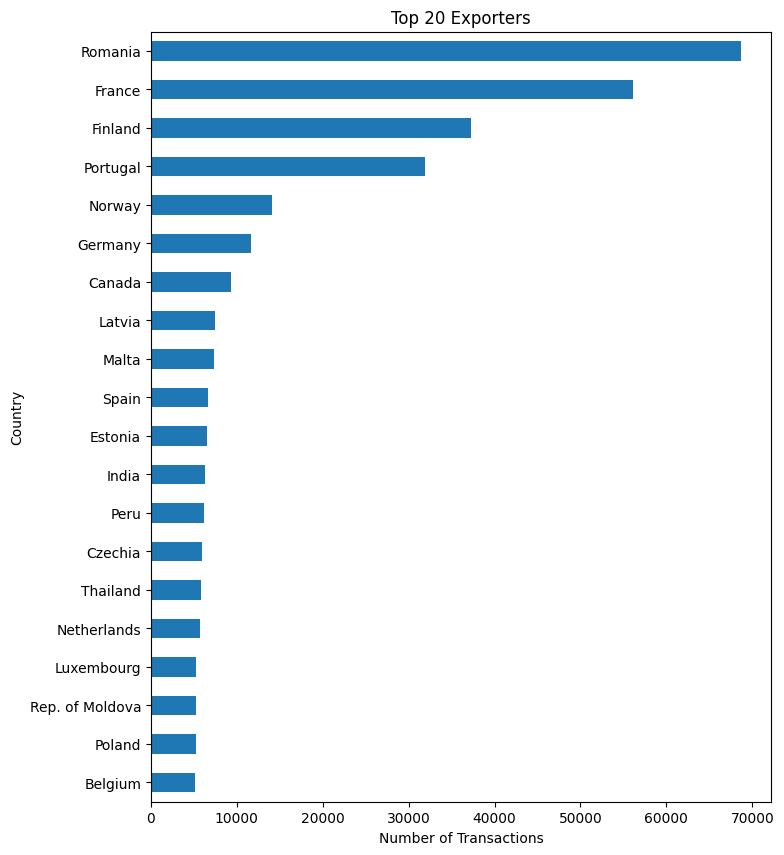

In [48]:
# From df_export
df_export['reporterDesc'].value_counts().head(20).plot(kind='barh', figsize=(8, 10))
plt.title("Top 20 Exporters")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.show()

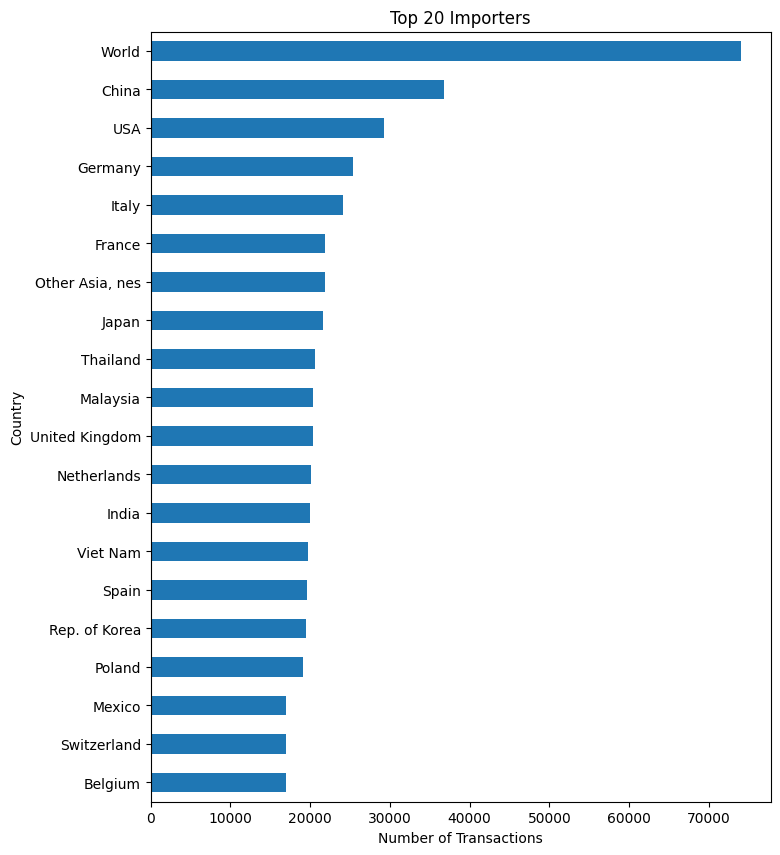

In [49]:
# From df_import
df_import['partnerDesc'].value_counts().head(20).plot(kind='barh', figsize=(8, 10))
plt.title("Top 20 Importers")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.show()

#### Importers

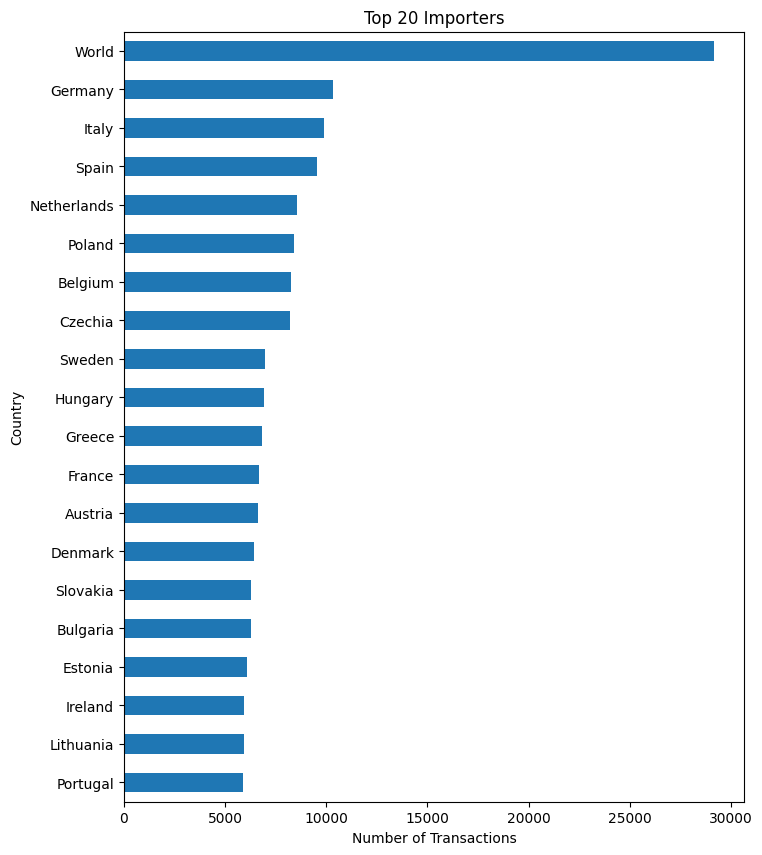

In [50]:
# From df_export
df_export['partnerDesc'].value_counts().head(20).plot(kind='barh', figsize=(8, 10))
plt.title("Top 20 Importers")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.show()

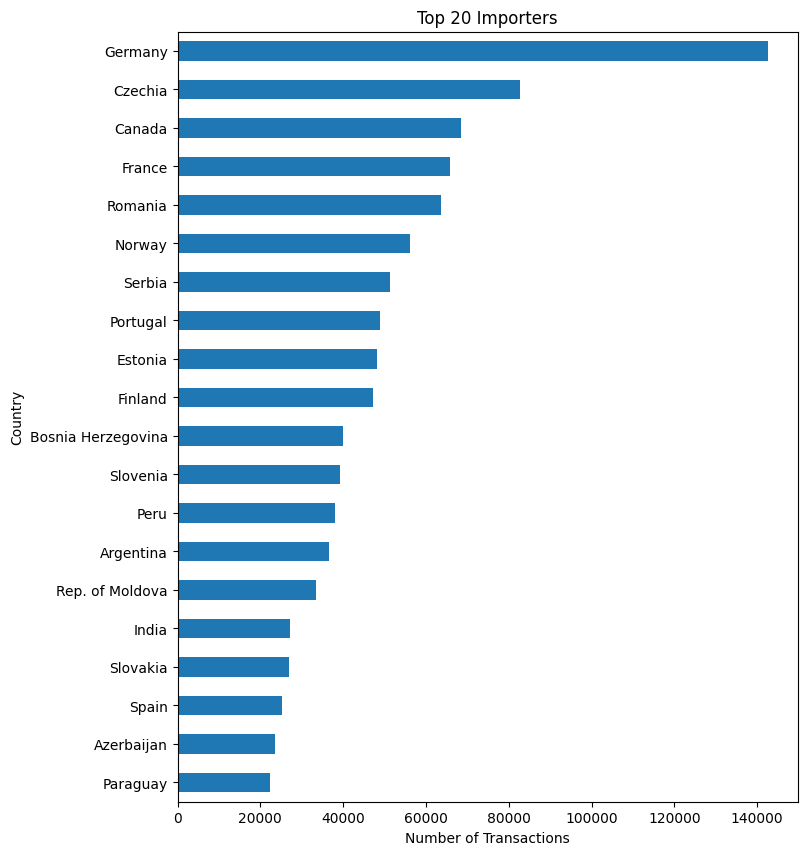

In [51]:
# From df_import
df_import['reporterDesc'].value_counts().head(20).plot(kind='barh', figsize=(8, 10))
plt.title("Top 20 Importers")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.show()

#### Insight:
We can take a data either import or export from both export report or import report. However, we will have some aggregation data from the opposite report such as taking an export data from import report which exporter will be as 'partner' and the 'reporter' will be the import country. The reporter somehow create a aggregation data such as 'World' as their 'partner'. So we have to focus on the 'reporter' only to avoid aggregation data.

# Outlier Check

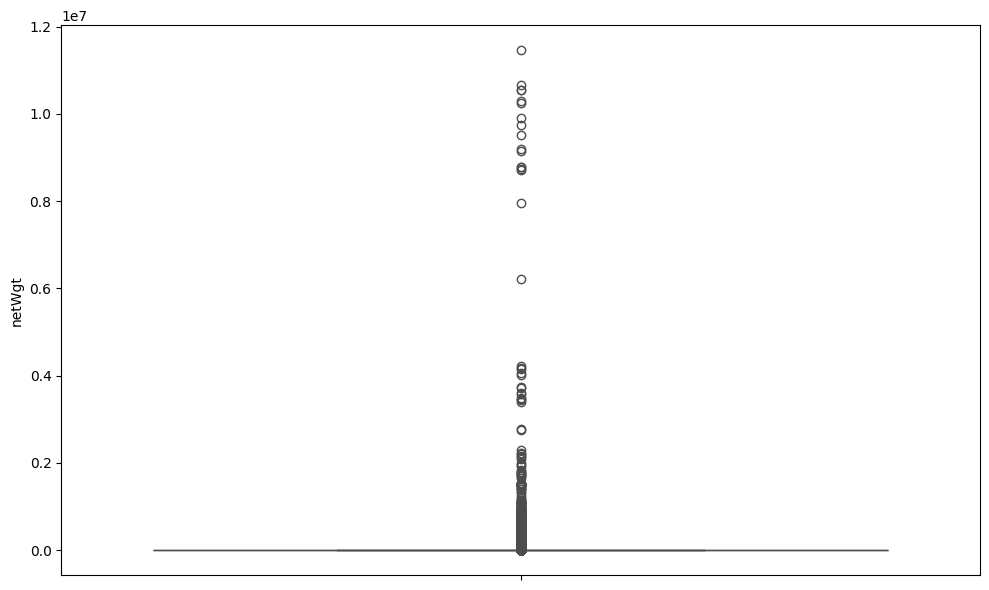

In [52]:
# Check outliers
numerical_columns = df_export.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(10, 6))
for i in range(0, len(numerical_columns)):
    plt.subplot(1,len(numerical_columns), i+1)
    sns.boxplot(y=df_export[numerical_columns[i]], color='blue')
    plt.tight_layout()

Since the operations value is the part that has outliers, we will keep the outliers, to keep the original information.

# Export Data for PBI uses

In [ ]:
df_export.to_excel('df_export.xlsx', index=False)

In [ ]:
df_import.to_excel('df_import.xlsx', index=False)

## Data of the quantity

In [53]:
zero_counts = df_export.apply(lambda x: (x == 0).sum())
print(zero_counts)

reporterCode    0
reporterDesc    0
partnerCode     0
partnerDesc     0
period          0
flowCode        0
flowDesc        0
cmdCode         0
cmdDesc         0
qty             0
fobvalue        0
netWgt          0
dtype: int64


In [54]:
# Drop rows where 'qty' is zero in df_export
df_export_qty = df_export[df_export['qty'] != 0].reset_index(drop=True)
df_export_qty.head()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,netWgt
0,36,Australia,238,Falkland Isds (Malvinas),202501,X,Export,TOTAL,All Commodities,0,1289.771,1515.220819
1,36,Australia,84,Belize,202501,X,Export,TOTAL,All Commodities,0,2085.918,1515.220819
2,36,Australia,0,World,202501,X,Export,TOTAL,All Commodities,0,25975646838.107,1515.220819
3,36,Australia,140,Central African Rep.,202501,X,Export,TOTAL,All Commodities,0,379.71,1515.220819
4,36,Australia,0,World,202501,X,Export,8542,Electronic integrated circuits,0,7397398.731,1515.220819


In [55]:
zero_counts = df_export_qty.apply(lambda x: (x == 0).sum())
print(zero_counts)

reporterCode    0
reporterDesc    0
partnerCode     0
partnerDesc     0
period          0
flowCode        0
flowDesc        0
cmdCode         0
cmdDesc         0
qty             0
fobvalue        0
netWgt          0
dtype: int64


In [56]:
df_export_qty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462778 entries, 0 to 462777
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   reporterCode  462778 non-null  object 
 1   reporterDesc  462778 non-null  object 
 2   partnerCode   462778 non-null  object 
 3   partnerDesc   462778 non-null  object 
 4   period        462778 non-null  object 
 5   flowCode      462778 non-null  object 
 6   flowDesc      462778 non-null  object 
 7   cmdCode       462778 non-null  object 
 8   cmdDesc       462778 non-null  object 
 9   qty           462778 non-null  object 
 10  fobvalue      462778 non-null  object 
 11  netWgt        462778 non-null  float64
dtypes: float64(1), object(11)
memory usage: 42.4+ MB


In [69]:
df_export_qty.to_excel('df_export_qty.xlsx', index=False)

KeyboardInterrupt: 

# Data Manipulation

In [57]:
# Select only columns with float or int data types from df_copy_clean
numeric_df = df_export.select_dtypes(include=['float64', 'int64'])
numeric_df.head()

,netWgt
0,1515.220819
1,1515.220819
2,1515.220819
3,1515.220819
4,1515.220819


In [58]:
def check_plot(df, variable):
    # fungsi mengambil kerangka data (df) dan
    # variabel yang diminati sebagai argumen

    # tentukan ukuran gambar
    plt.figure(figsize=(16, 4))

    # histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[variable], bins=30)
    plt.title('Histogram')

    # plot Q-Q
    plt.subplot(1, 3, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.ylabel('Variable quantiles')

    # box plot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[variable])
    plt.title('Boxplot')

    plt.show()

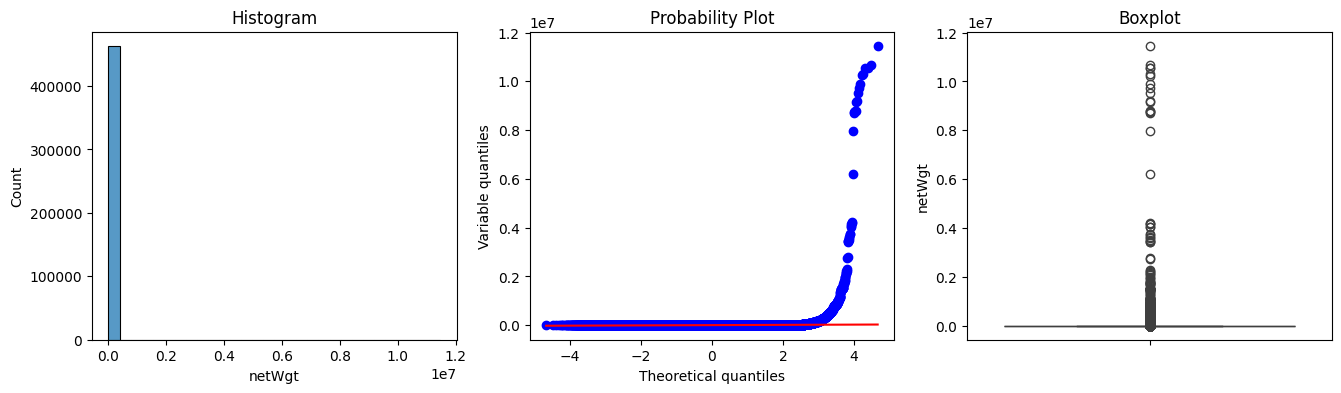

In [59]:
for col in numeric_df:
    check_plot(numeric_df, col)

There is nothing to conclude yet here.

In [60]:
# Convert fobvalue to numeric before aggregation
df_export['fobvalue'] = pd.to_numeric(df_export['fobvalue'], errors='coerce')
top_countries = df_export.groupby('reporterDesc')['fobvalue'].mean().sort_values(ascending=False).reset_index()
top_countries.head(10)

,reporterDesc,fobvalue
0,China,1.815496e+09
1,USA,1.135350e+09
2,Germany,8.341748e+08
3,Mexico,7.623158e+08
4,"China, Hong Kong SAR",5.035496e+08
5,Rep. of Korea,4.922281e+08
6,Japan,4.707945e+08
7,Italy,3.768041e+08
8,Netherlands,3.640837e+08
9,Canada,3.630494e+08


C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_22828\1022818561.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries.head(10), x='fobvalue', y='reporterDesc', palette='viridis')


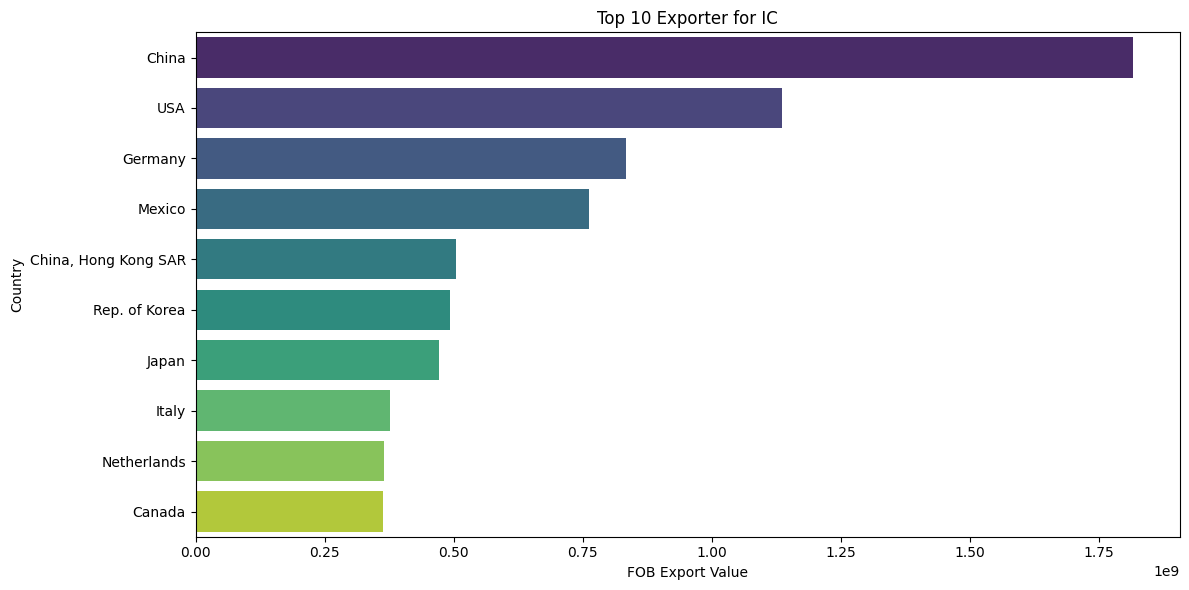

In [61]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_countries.head(10), x='fobvalue', y='reporterDesc', palette='viridis')
plt.title('Top 10 Exporter for IC')
plt.xlabel('FOB Export Value')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

<Axes: xlabel='period'>

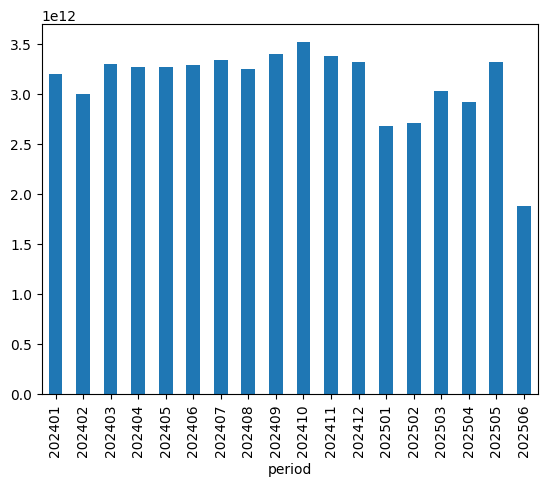

In [62]:
df_export.groupby(['period'])['fobvalue'].sum().plot(kind='bar')

In [64]:
# a. Trend analysis over time
trend_df = df_export.groupby("period")["fobvalue"].sum().reset_index()
trend_df

,period,fobvalue
0,202401,3.202391e+12
1,202402,2.999158e+12
2,202403,3.298153e+12
3,202404,3.272380e+12
4,202405,3.271208e+12
5,202406,3.284416e+12
6,202407,3.334472e+12
7,202408,3.242478e+12
8,202409,3.395185e+12
9,202410,3.517545e+12


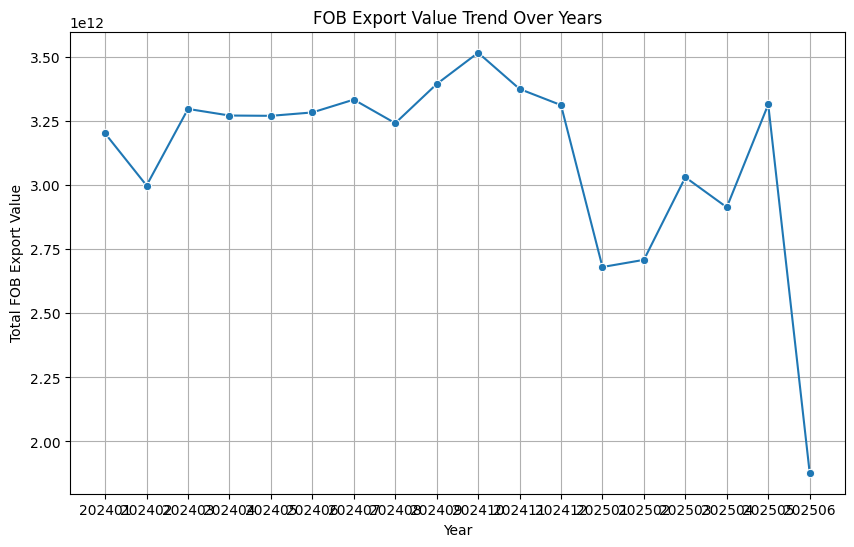

In [66]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=trend_df, x='period', y='fobvalue', marker='o')
plt.title('FOB Export Value Trend Over Years')
plt.xlabel('Year')
plt.ylabel('Total FOB Export Value')
plt.grid(True)
plt.show()

In [67]:
# Calculate export value per kg
df_export["value_per_kg"] = df_export["fobvalue"] / df_export["netWgt"]

In [68]:
# b. Avg export value/kg by country
value_per_kg_df = df_export.groupby("reporterDesc")["value_per_kg"].mean().reset_index()
value_per_kg_df = value_per_kg_df.sort_values(by="value_per_kg", ascending=False).head(20)
value_per_kg_df

,reporterDesc,value_per_kg
17,China,1.147880e+06
90,USA,7.492966e+05
35,Germany,5.454561e+05
58,Mexico,5.031042e+05
47,Japan,3.042146e+05
18,"China, Hong Kong SAR",2.904569e+05
75,Rep. of Korea,2.771839e+05
46,Italy,2.487865e+05
64,Netherlands,2.397157e+05
15,Canada,2.396016e+05


C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_22828\769833094.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=value_per_kg_df, x='value_per_kg', y='reporterDesc', palette='mako')


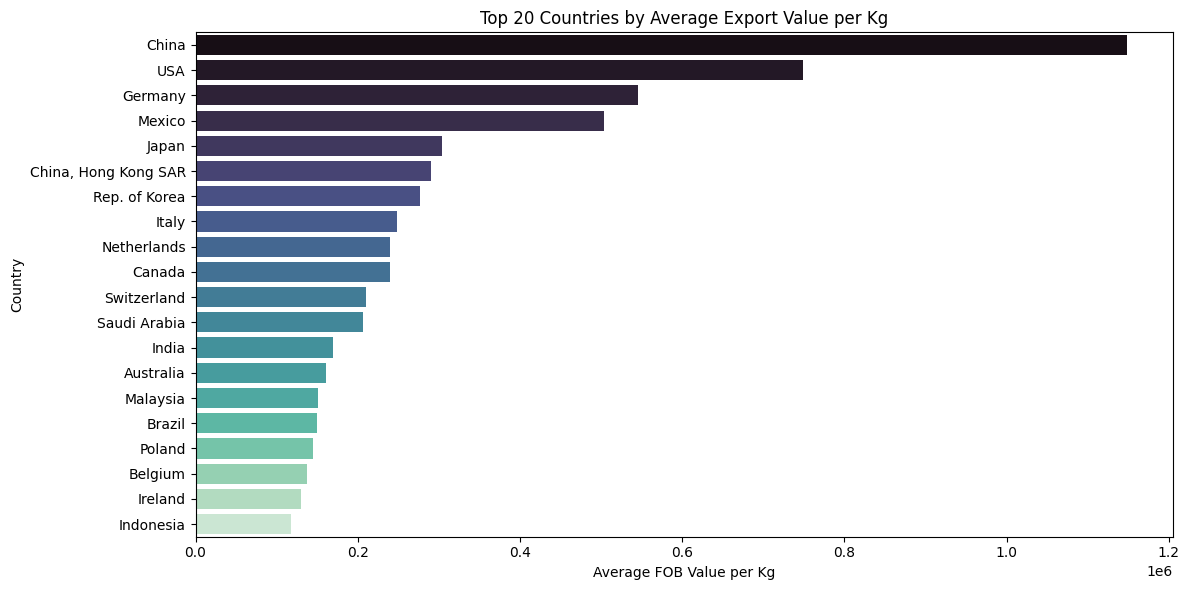

In [69]:
plt.figure(figsize=(12, 6))
sns.barplot(data=value_per_kg_df, x='value_per_kg', y='reporterDesc', palette='mako')
plt.title('Top 20 Countries by Average Export Value per Kg')
plt.xlabel('Average FOB Value per Kg')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [70]:
importer_value_per_kg_df = df_export.groupby("partnerDesc").agg(
    total_fobvalue=("fobvalue", "sum"),
    total_netwgt=("netWgt", "sum")
).reset_index()

In [71]:
# Calculate value per kg
importer_value_per_kg_df["value_per_kg"] = (
    importer_value_per_kg_df["total_fobvalue"] / importer_value_per_kg_df["total_netwgt"]
)
importer_value_per_kg_df = importer_value_per_kg_df.sort_values(by="value_per_kg", ascending=False).head(20)


C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_22828\491785898.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importer_value_per_kg_df, x='value_per_kg', y='partnerDesc', palette='mako')
C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_22828\491785898.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=value_per_kg_df, x='value_per_kg', y='reporterDesc', palette='mako')


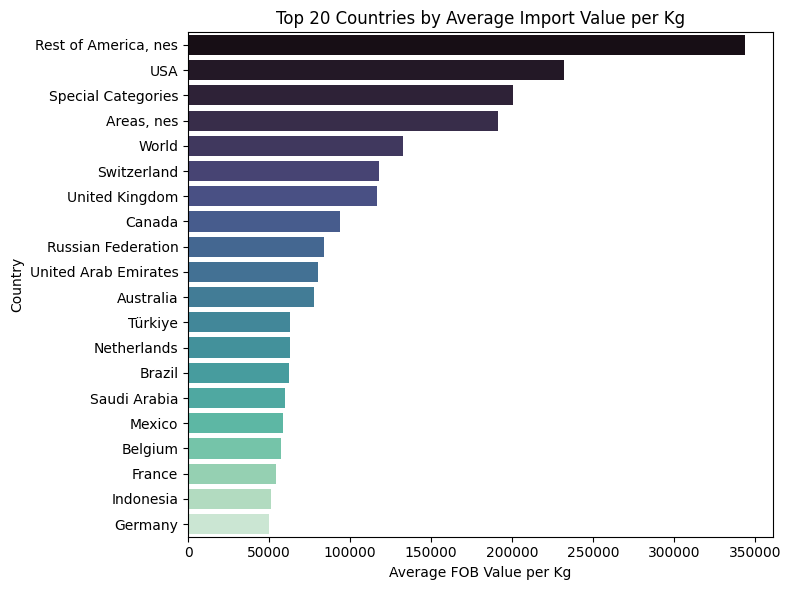

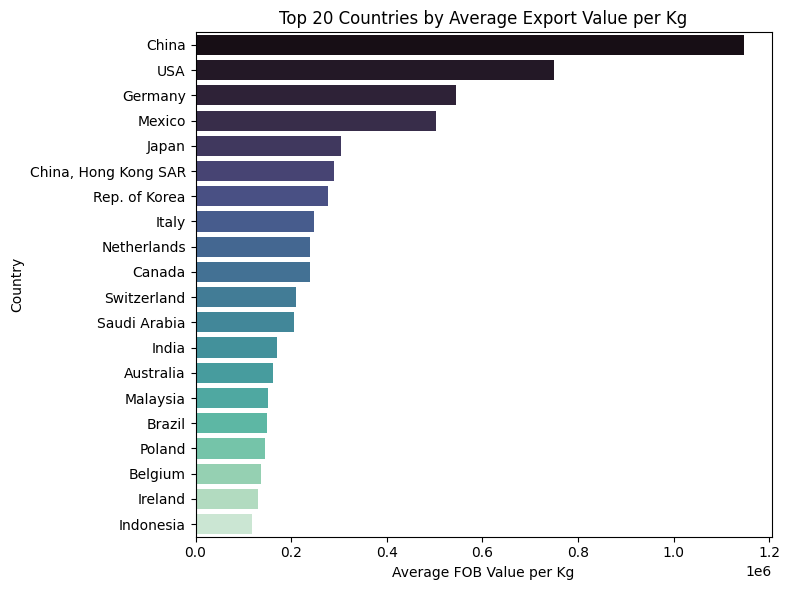

In [72]:
plt.figure(figsize=(8, 6))
sns.barplot(data=importer_value_per_kg_df, x='value_per_kg', y='partnerDesc', palette='mako')
plt.title('Top 20 Countries by Average Import Value per Kg')
plt.xlabel('Average FOB Value per Kg')
plt.ylabel('Country')
plt.tight_layout()

plt.figure(figsize=(8, 6))
sns.barplot(data=value_per_kg_df, x='value_per_kg', y='reporterDesc', palette='mako')
plt.title('Top 20 Countries by Average Export Value per Kg')
plt.xlabel('Average FOB Value per Kg')
plt.ylabel('Country')
plt.tight_layout()

plt.show()

C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_22828\101735088.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_importers_filtered, y="partnerDesc", x="value_per_kg", palette="viridis")


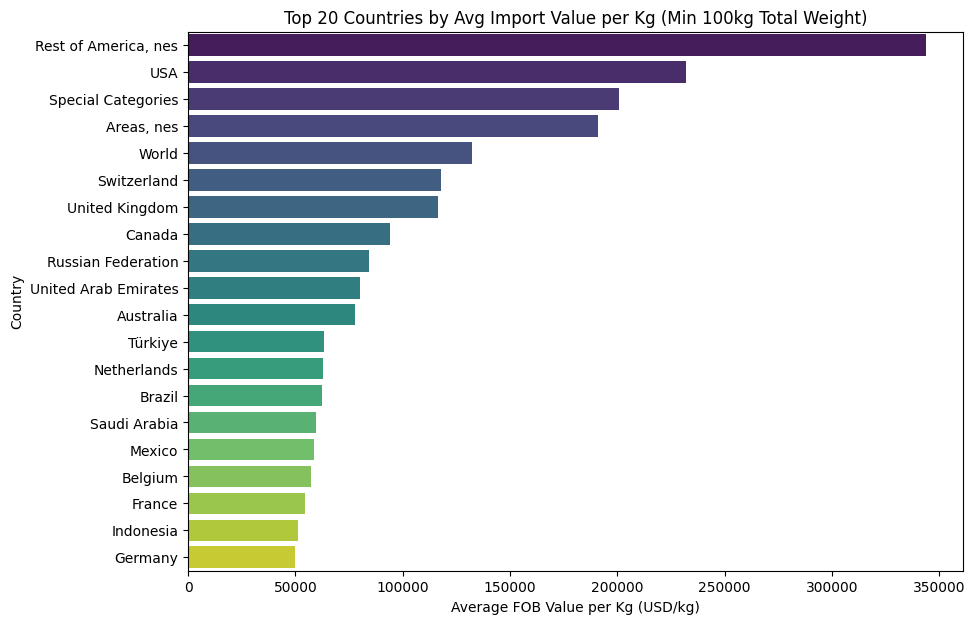

In [73]:
# Apply threshold: remove countries with too small total weight (e.g., <100kg)
filtered_df = importer_value_per_kg_df[importer_value_per_kg_df["total_netwgt"] > 100]

# Get top 20 by FOB value
top_importers_filtered = filtered_df.sort_values(by="value_per_kg", ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 7))
sns.barplot(data=top_importers_filtered, y="partnerDesc", x="value_per_kg", palette="viridis")
plt.title("Top 20 Countries by Avg Import Value per Kg (Min 100kg Total Weight)")
plt.xlabel("Average FOB Value per Kg (USD/kg)")
plt.ylabel("Country")
plt.show()


Move to PBI to make a complete visualization, and conclusion. Business recommendation is in Powerpoint.

In [76]:
# Top exporters by FOB
top_exp = (df_copy_export.groupby('reporterDesc')['fobvalue']
                 .sum().sort_values(ascending=False).head(10))

# Convert netWgt and fobvalue to numeric
df_copy_export['netWgt'] = pd.to_numeric(df_copy_export['netWgt'], errors='coerce')
df_copy_export['fobvalue'] = pd.to_numeric(df_copy_export['fobvalue'], errors='coerce')

# Weighted $/kg with a weight floor (e.g., 1,000 kg)
g = df_copy_export[(df_copy_export['netWgt'] > 0) & (df_copy_export['fobvalue'] > 0)] \
        .groupby('reporterDesc').agg(val=('fobvalue','sum'),
                                     wgt=('netWgt','sum'))
g['usd_per_kg'] = g['val'] / g['wgt']
price_rank = g[g['wgt'] >= 1000].sort_values('usd_per_kg', ascending=False).head(10)

C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_22828\535947027.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_export['netWgt'] = pd.to_numeric(df_copy_export['netWgt'], errors='coerce')
C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_22828\535947027.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_export['fobvalue'] = pd.to_numeric(df_copy_export['fobvalue'], errors='coerce')


x value (usd_per_kg):
reporterDesc
USA             749296.629544
Mexico          502810.898751
Canada          239601.621297
Switzerland     237964.153868
Saudi Arabia    180726.951424
India           179880.094660
Brazil          173297.349373
Australia       161743.535628
Netherlands     142555.960519
Ireland         140112.006628
Name: usd_per_kg, dtype: float64


C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_22828\2912927662.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=price_rank, x='usd_per_kg', y=price_rank.index, palette="viridis")
C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_22828\2912927662.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


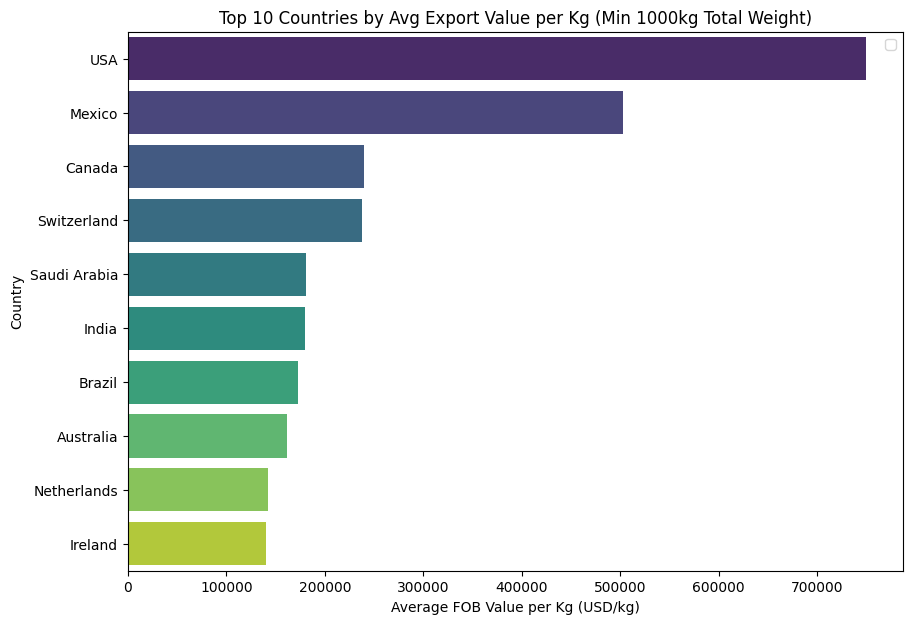

In [77]:
# Plot
plt.figure(figsize=(10, 7))
sns.barplot(data=price_rank, x='usd_per_kg', y=price_rank.index, palette="viridis")
plt.title("Top 10 Countries by Avg Export Value per Kg (Min 1000kg Total Weight)")
plt.xlabel("Average FOB Value per Kg (USD/kg)")
plt.ylabel("Country")
plt.legend()
print("x value (usd_per_kg):")
print(price_rank['usd_per_kg'])
plt.show()

# Machine learning

In [79]:
dfe = df_copy_export.copy()

# Prefer primaryValue then fobvalue (rule #5). Coerce numerics once.
for c in ["primaryValue","fobvalue","netWgt"]:
    if c in dfe.columns:
        dfe[c] = pd.to_numeric(dfe[c], errors="coerce")
if "value" not in dfe.columns:
    dfe["value"] = dfe["primaryValue"]
    dfe.loc[dfe["value"].isna(), "value"] = dfe["fobvalue"]

# Keep positive rows only (rule #6).
dfe = dfe[(dfe["value"] > 0) & (dfe["netWgt"] > 0)]

# Clean 'period' to 6-digit YYYYMM and create ref_date (avoid cross-year mixing).
dfe["period"]  = pd.to_numeric(dfe["period"].astype(str).str.extract(r"(\d{6})")[0], errors="coerce").astype("Int64")
dfe = dfe[dfe["period"].notna()]
yy = (dfe["period"] // 100).astype(int)
mm = (dfe["period"] % 100).astype(int)
dfe["ref_date"] = pd.to_datetime(dict(year=yy, month=mm, day=1), errors="coerce")

In [80]:
# ---------- 1) Monthly aggregates (ratio-of-sums for USD/kg, rule #7) ---------
monthly = (dfe.groupby(["period","ref_date"], as_index=False)
             .agg(total_value=("value","sum"),
                  total_kg=("netWgt","sum"),
                  shipments=("value","size"),
                  n_reporters=("reporterDesc","nunique"),
                  n_partners=("partnerDesc","nunique")))
monthly["usd_per_kg"] = monthly["total_value"] / monthly["total_kg"]
monthly = monthly.sort_values("ref_date").reset_index(drop=True)

In [81]:
# ---------- 2) Feature engineering -------------------------------------------
def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    d["year"]  = d["ref_date"].dt.year
    d["month"] = d["ref_date"].dt.month
    d["qtr"]   = ((d["month"]-1)//3 + 1)

    # Lags for targets + useful covariates
    for col in ["total_value","total_kg","usd_per_kg","shipments","n_reporters","n_partners"]:
        for L in [1,3,6,12]:
            d[f"{col}_lag{L}"] = d[col].shift(L)

    # Rolls & volatility
    d["tv_roll3"]  = d["total_value"].rolling(3).mean()
    d["tv_roll6"]  = d["total_value"].rolling(6).mean()
    d["tv_roll12"] = d["total_value"].rolling(12).mean()
    d["tv_std6"]   = d["total_value"].rolling(6).std()

    # Growth rates
    d["tv_mom"] = d["total_value"].pct_change(1)
    d["tv_qoq"] = d["total_value"].pct_change(3)
    d["tv_yoy"] = d["total_value"].pct_change(12)

    d = d.replace([np.inf, -np.inf], np.nan)
    return d

features = add_time_features(monthly)

In [82]:
# ---------- 3) Backtesting (expanding window, 1-step ahead) -------------------
def mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def smape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred))
    mask = denom != 0
    return np.mean(2.0 * np.abs(y_pred[mask] - y_true[mask]) / denom[mask]) * 100

def prepare_xy(d, target="total_value"):
    X = d.dropna(subset=[f"{target}_lag1", f"{target}_lag3"]).copy()
    y = X[target].copy()
    feats = [c for c in X.columns if any([
        c.startswith("total_value_lag"),
        c.startswith("total_kg_lag"),
        c.startswith("usd_per_kg_lag"),
        c.startswith("shipments_lag"),
        c.startswith("n_reporters_lag"),
        c.startswith("n_partners_lag"),
        c in ["tv_roll3","tv_roll6","tv_roll12","tv_std6","tv_mom","tv_qoq","tv_yoy","month","qtr"]
    ])]
    X["t"] = np.arange(len(X)); feats.append("t")
    return X, y, feats

Xall, yall, feats = prepare_xy(features, target="total_value")
splits = [(np.arange(0, t), np.array([t])) for t in range(12, len(Xall))]  # start after 12 months

In [83]:
# Baselines
def pred_naive(y_tr):    return np.repeat(y_tr.iloc[-1], 1)
def pred_snaive(y_tr,s=12): 
    return np.repeat(y_tr.iloc[-s] if len(y_tr)>=s else y_tr.iloc[-1], 1)

In [84]:
# Optional models (use if available)
use_sarimax = True
use_hgb = True
try:
    from statsmodels.tsa.statespace.sarimax import SARIMAX
except Exception:
    use_sarimax = False
try:
    from sklearn.experimental import enable_hist_gradient_boosting  # noqa: F401
    from sklearn.ensemble import HistGradientBoostingRegressor
except Exception:
    use_hgb = False

In [85]:
preds = {"Naive":[], "SNaive12":[]}
if use_sarimax: preds["SARIMAX"] = []
if use_hgb:     preds["HGB"]     = []
y_true_list = []

for tr_idx, te_idx in splits:
    y_tr = yall.iloc[tr_idx]; y_te = yall.iloc[te_idx]
    X_tr = Xall.iloc[tr_idx]; X_te = Xall.iloc[te_idx]
    y_true_list.append(y_te.values[0])

    preds["Naive"].append(pred_naive(y_tr)[0])
    preds["SNaive12"].append(pred_snaive(y_tr)[0])

    if use_sarimax:
        try:
            res = SARIMAX(y_tr, order=(1,1,1), seasonal_order=(0,1,1,12),
                          enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            preds["SARIMAX"].append(float(res.forecast(1).iloc[0]))
        except Exception:
            preds["SARIMAX"].append(pred_snaive(y_tr)[0])

    if use_hgb:
        try:
            hgb = HistGradientBoostingRegressor(max_iter=600, learning_rate=0.05, early_stopping=True)
            hgb.fit(X_tr[feats], y_tr)
            preds["HGB"].append(float(hgb.predict(X_te[feats])[0]))
        except Exception:
            preds["HGB"].append(pred_naive(y_tr)[0])

In [89]:
# Metrics leaderboard
yt = np.array(y_true_list)
leaderboard = pd.DataFrame([{
    "model": name,
    "MAE": mean_absolute_error(yt, np.array(pv)),
    "RMSE": sqrt(mean_squared_error(yt, np.array(pv))),
    "MAPE%": mape(yt, np.array(pv)),
    "sMAPE%": smape(yt, np.array(pv))
} for name, pv in preds.items()]).sort_values(["RMSE","MAE"]).reset_index(drop=True)

In [90]:
# ---------- 4) Final fit & forecasts (next 3 / 6 months) ----------------------
last_date = features["ref_date"].max()
f3 = pd.date_range(last_date + pd.offsets.MonthBegin(1), periods=3, freq="MS")
f6 = pd.date_range(last_date + pd.offsets.MonthBegin(1), periods=6, freq="MS")

# SARIMAX forecasts
fc_sar_3 = fc_sar_6 = None
if use_sarimax and len(yall) >= 13:
    try:
        res_full = SARIMAX(yall, order=(1,1,1), seasonal_order=(0,1,1,12),
                           enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        fc_sar_3 = np.asarray(res_full.forecast(3))
        fc_sar_6 = np.asarray(res_full.forecast(6))
    except Exception:
        pass


In [91]:
# HGB recursive forecasts
def hgb_forecast(feat_df, steps=6):
    if not use_hgb: return None
    df = feat_df.copy()
    X, y, feat_names = prepare_xy(df, "total_value")
    if len(X) < 3: return None
    model = HistGradientBoostingRegressor(max_iter=600, learning_rate=0.05, early_stopping=True)
    model.fit(X[feat_names], y)
    preds = []
    df_ext = df.copy()
    for _ in range(steps):
        df_ext = add_time_features(df_ext)
        Xr, _, fn = prepare_xy(df_ext, "total_value")
        y_hat = float(model.predict(Xr.iloc[[-1]][fn])[0])
        preds.append(y_hat)

        # append a synthetic next month with simple carry-forwards for exog vars
        next_date = df_ext["ref_date"].max() + pd.offsets.MonthBegin(1)
        next_row = df_ext.iloc[[-1]].copy()
        next_row["ref_date"] = next_date
        next_row["period"]   = int(next_date.year*100 + next_date.month)
        next_row["total_value"] = y_hat
        for c in ["total_kg","usd_per_kg","shipments","n_reporters","n_partners"]:
            next_row[c] = df_ext[c].iloc[-1]
        df_ext = pd.concat([df_ext, next_row], ignore_index=True)
    return np.array(preds)

In [92]:
fc_hgb_3 = hgb_forecast(features, steps=3)
fc_hgb_6 = hgb_forecast(features, steps=6)

In [93]:
# Forecast tables
fc_table_3 = pd.DataFrame({"ref_date": f3})
fc_table_6 = pd.DataFrame({"ref_date": f6})
if fc_sar_3 is not None: fc_table_3["SARIMAX_total_value"] = fc_sar_3
if fc_hgb_3 is not None: fc_table_3["HGB_total_value"]     = fc_hgb_3
if fc_sar_6 is not None: fc_table_6["SARIMAX_total_value"] = fc_sar_6
if fc_hgb_6 is not None: fc_table_6["HGB_total_value"]     = fc_hgb_6

In [94]:
# ---------- 5) Outputs --------------------------------------------------------
display(leaderboard)      # Model comparison on rolling backtest
display(monthly.tail())   # Latest monthly aggregates
display(fc_table_3)       # Next 3 months forecast
display(fc_table_6)       # Next 6 months forecast

,model,MAE,RMSE,MAPE%,sMAPE%
0,SNaive12,6.030425e+11,8.383307e+11,29.508340,22.472956
1,Naive,6.521534e+11,8.644476e+11,30.895948,24.066074


,period,ref_date,total_value,total_kg,shipments,n_reporters,n_partners,usd_per_kg
13,202502,2025-02-01,2.708961e+12,6.618156e+07,26421,66,244,40932.255721
14,202503,2025-03-01,3.031402e+12,7.837298e+07,24200,67,243,38679.178604
15,202504,2025-04-01,2.914110e+12,6.614230e+07,24136,60,243,44058.182178
16,202505,2025-05-01,3.315628e+12,6.518526e+07,24317,61,243,50864.694521
17,202506,2025-06-01,1.877979e+12,3.093221e+07,13946,44,240,60712.748893


,ref_date
0,2025-07-01
1,2025-08-01
2,2025-09-01


,ref_date
0,2025-07-01
1,2025-08-01
2,2025-09-01
3,2025-10-01
4,2025-11-01
5,2025-12-01


In [95]:
# 0) Helper: build a backtest DataFrame from what we already computed
#    (dates of each one-step test + each model's prediction)
test_dates = [Xall.iloc[te_idx]["ref_date"].values[0] for _, te_idx in splits]
bt = pd.DataFrame({"ref_date": test_dates, "y_true": np.array(y_true_list)})

In [96]:
for name, pv in preds.items():
    bt[f"pred_{name}"] = np.array(pv)

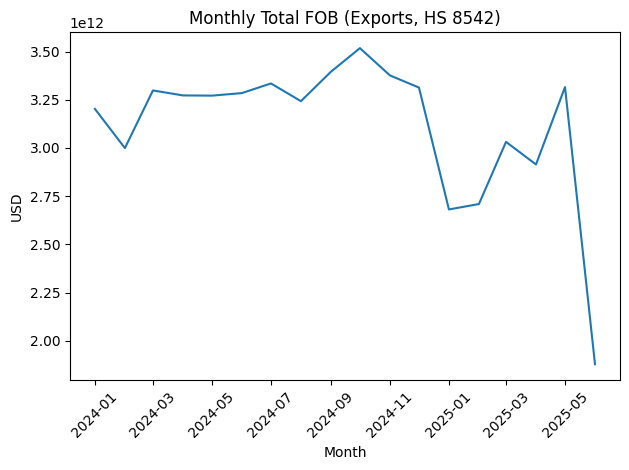

In [97]:
# 1) Monthly totals (FOB)
plt.figure()
plt.plot(monthly["ref_date"], monthly["total_value"])
plt.title("Monthly Total FOB (Exports, HS 8542)")
plt.xlabel("Month")
plt.ylabel("USD")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

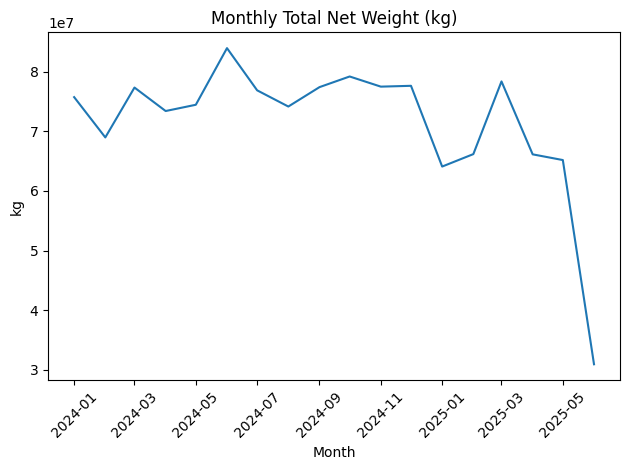

In [98]:
# 2) Monthly total kg
plt.figure()
plt.plot(monthly["ref_date"], monthly["total_kg"])
plt.title("Monthly Total Net Weight (kg)")
plt.xlabel("Month")
plt.ylabel("kg")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

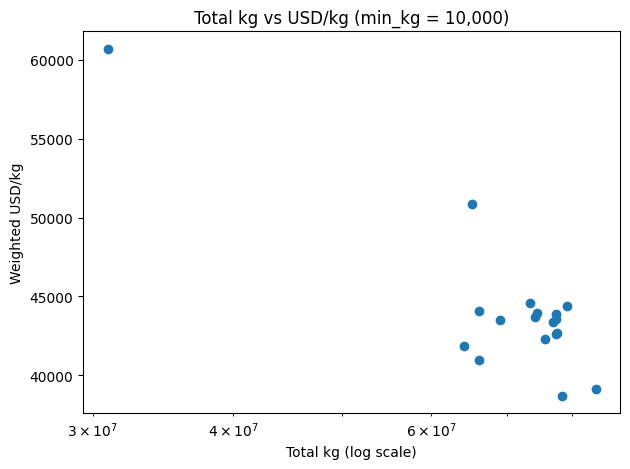

In [99]:
# 3) Scatter: total kg vs weighted USD/kg (log-x), label outliers
min_kg = 10_000  # change to 1_000 or 50_000 to test sensitivity
m = monthly[monthly["total_kg"] >= min_kg].copy()

plt.figure()
plt.scatter(m["total_kg"], m["usd_per_kg"])
plt.xscale("log")
plt.title(f"Total kg vs USD/kg (min_kg = {min_kg:,})")
plt.xlabel("Total kg (log scale)")
plt.ylabel("Weighted USD/kg")
plt.tight_layout()
plt.show()

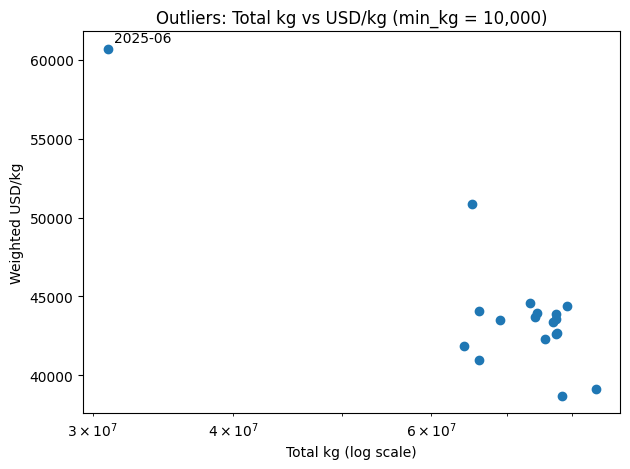

In [100]:
# Optional: label top/bottom outliers by USD/kg z-score
if len(m) >= 5:
    z = (m["usd_per_kg"] - m["usd_per_kg"].mean()) / m["usd_per_kg"].std()
    label_mask = (z.abs() > 2)  # tweak threshold
    if label_mask.any():
        plt.figure()
        plt.scatter(m["total_kg"], m["usd_per_kg"])
        plt.xscale("log")
        for _, r in m[label_mask].iterrows():
            lbl = r["ref_date"].strftime("%Y-%m")
            plt.annotate(lbl, (r["total_kg"], r["usd_per_kg"]), xytext=(5,5), textcoords="offset points")
        plt.title(f"Outliers: Total kg vs USD/kg (min_kg = {min_kg:,})")
        plt.xlabel("Total kg (log scale)")
        plt.ylabel("Weighted USD/kg")
        plt.tight_layout()
        plt.show()

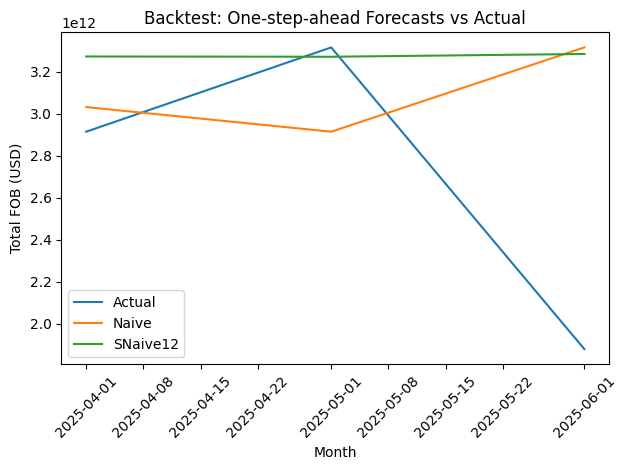

In [101]:
# 4) Backtest: actual vs predictions (one-step-ahead)
plt.figure()
plt.plot(bt["ref_date"], bt["y_true"], label="Actual")
for name in preds.keys():
    plt.plot(bt["ref_date"], bt[f"pred_{name}"], label=name)
plt.title("Backtest: One-step-ahead Forecasts vs Actual")
plt.xlabel("Month")
plt.ylabel("Total FOB (USD)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

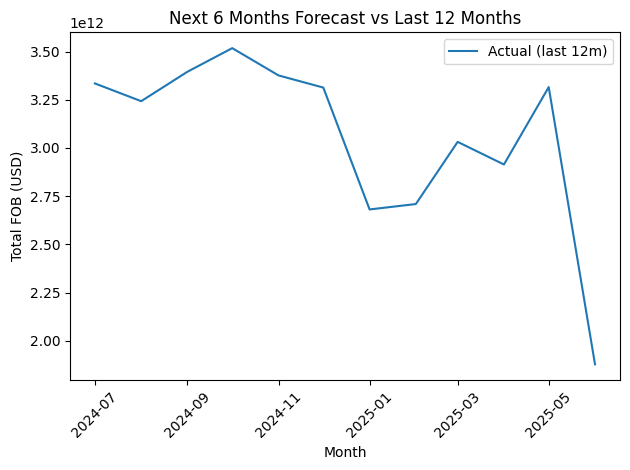

In [104]:
# 5) Forecasts: next 6 months vs recent history
#    (Overlay last 12 months actual with future predictions)
hist_span = 12
hist = monthly.tail(hist_span)

plt.figure()
plt.plot(hist["ref_date"], hist["total_value"], label="Actual (last 12m)")

# If SARIMAX/HGB forecasts exist, plot them
if "SARIMAX_total_value" in fc_table_6.columns:
    plt.plot(fc_table_6["ref_date"], fc_table_6["SARIMAX_total_value"], label="SARIMAX forecast")
if "HGB_total_value" in fc_table_6.columns:
    plt.plot(fc_table_6["ref_date"], fc_table_6["HGB_total_value"], label="HGB forecast")

plt.title("Next 6 Months Forecast vs Last 12 Months")
plt.xlabel("Month")
plt.ylabel("Total FOB (USD)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()